# Game of Life mosaics - Playground

In this Notebook we will take a look at some of the parameters that are parsed to the `MosaicGenerator` class. By playing around with them, it will become clear that you can easily generate many pretty variations of the same input image. We will take a look at the effect of ...
1. Tile levels
2. grid sizes
3. Colour schemes
4. ECA rules
5. Supersample values
6. Threshold values for the white (empty) Tiles
7. Threshold value for alpha cutoff

In [1]:
# Import libraries
import matplotlib.pyplot as plt

# Import gol_mosaics (installed with: pip install -e .)
from gol_mosaics import MosaicGenerator, ColorScheme

%load_ext autoreload
%autoreload 2

We'll work with a famous photo of Marilyn Monroe.

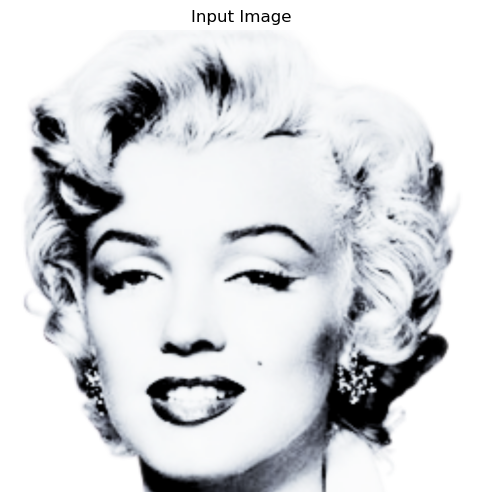

In [2]:
from PIL import Image

# Load input image
input_path = '../input/images/marilyn.png'
input_image = Image.open(input_path)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(input_image)
plt.title('Input Image')
plt.axis('off')
plt.show()

## 1. Tile level

The level of the Tile determines its width, which is simply `level` times the width of a single pond (see `tile_generation.ipynb` for details). Wider tiles can accommodate more static patterns:
- level 2: 2 patterns
- level 3: 7 patterns
- level 4: 85 patterns
- level 5: 2632 patterns

A larger number of patterns also means that there will be a larger variety in the density of living cells. This in turn means that greyscale value of pixels can be more faithfully mapped to density values of Tiles.

In short: higher level means better greyscale representation.

In [37]:
# we'll keep some values fixed in order to only display the effect the Tile level, and remove the ECA background for now
grid_size = 50
no_eca = True

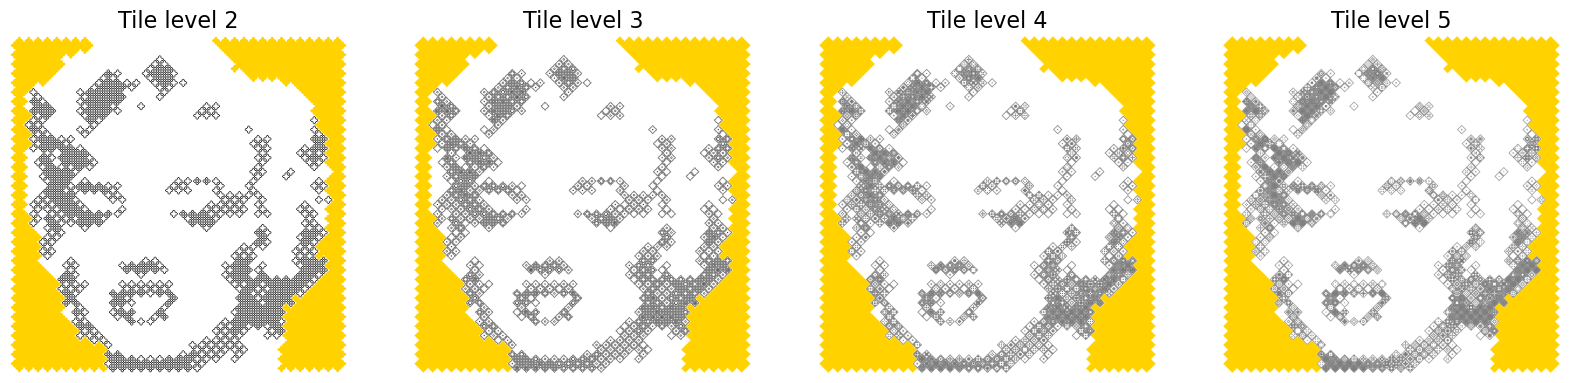

In [38]:
# create dict of generator classes for each level

levels = [2, 3, 4, 5]

generators_levels = {
    level: MosaicGenerator(level=level, grid_size=grid_size)
    for level in levels
}

mosaics_levels = {
    level: generator.generate_from_image(input_path, no_eca=no_eca)
    for level, generator in generators_levels.items()
}

fig, axs = plt.subplots(1,len(levels), figsize=(20, 5))

for ax, level in zip(axs, levels):
    ax.imshow(mosaics_levels[level])
    ax.set_title(f'Tile level {level}', fontsize=16)
    ax.axis('off')

## 2. Grid sizes

The grid size of the Mosaic determines its height, i.e. the number of Tile that fit vertically into the resulting image. The larger the grid size, the more detail can be represented by the Mosaic. High values of the grid size will become computationally demanding, however, especially if the level parameter is set to a relatively high value as well.

In short: higher grid size means higher resolution.

In [39]:
# we'll keep some values fixed in order to only display the effect the Tile level, and remove the ECA background for now
level = 4
no_eca = True

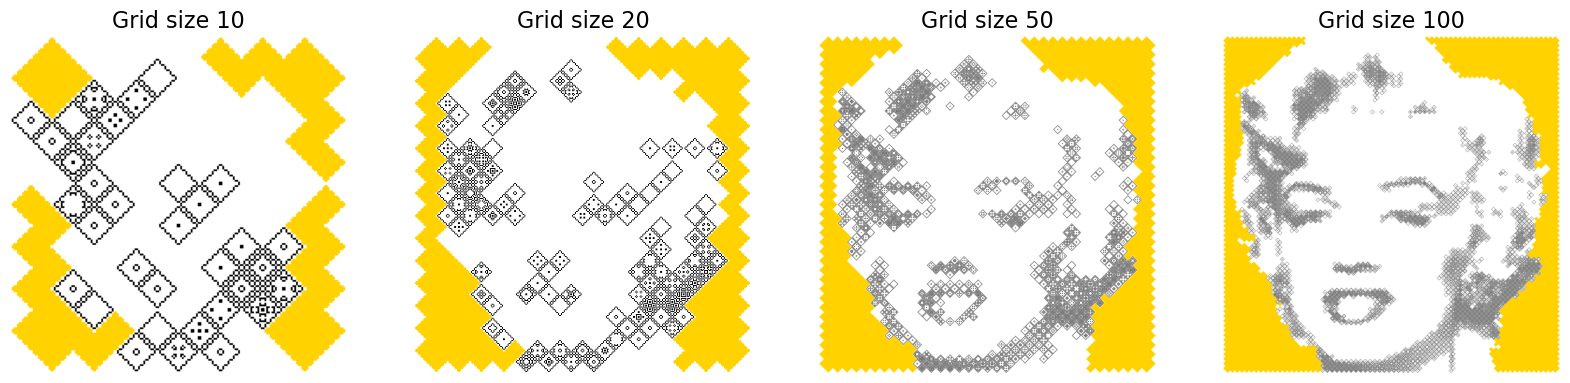

In [ ]:
# create dict of generator classes for each grid size

grid_sizes = [10, 20, 50, 100]

generators_grid_sizes = {
    grid_size: MosaicGenerator(level=level, grid_size=grid_size)
    for grid_size in grid_sizes
}

mosaics_grid_sizes = {
    grid_size: generator.generate_from_image(input_path, no_eca=no_eca)
    for grid_size, generator in generators_grid_sizes.items()
}

fig, axs = plt.subplots(1,len(grid_sizes), figsize=(20, 5))

for ax, grid_size in zip(axs, grid_sizes):
    ax.imshow(mosaics_grid_sizes[grid_size])
    ax.set_title(f'Grid size {grid_size}', fontsize=16)
    ax.axis('off')

## 3. Colour Schemes

By default, the colour scheme of Ghent University is used:
- white for the dead cells in the Game of Life
- black for the living cells in the Game of Life
- yellow for the dead cells in the elementary CA
- blue for the living cells in the elementary CA (currently disabled)

However, we may of course choose our own colour palette. A number of pretty bright colour have been pre-selected in the `ColorScheme.warhol` method. Check it out! Run the script a couple of time to get different colour combinations.

You may also select your own preferred colours by parsing hex strings to the `ColorScheme.custom` method.

In [41]:
# we'll keep some values fixed in order to only display the effect the Tile level, and remove the ECA background for now
level = 4
grid_size = 100
no_eca = True

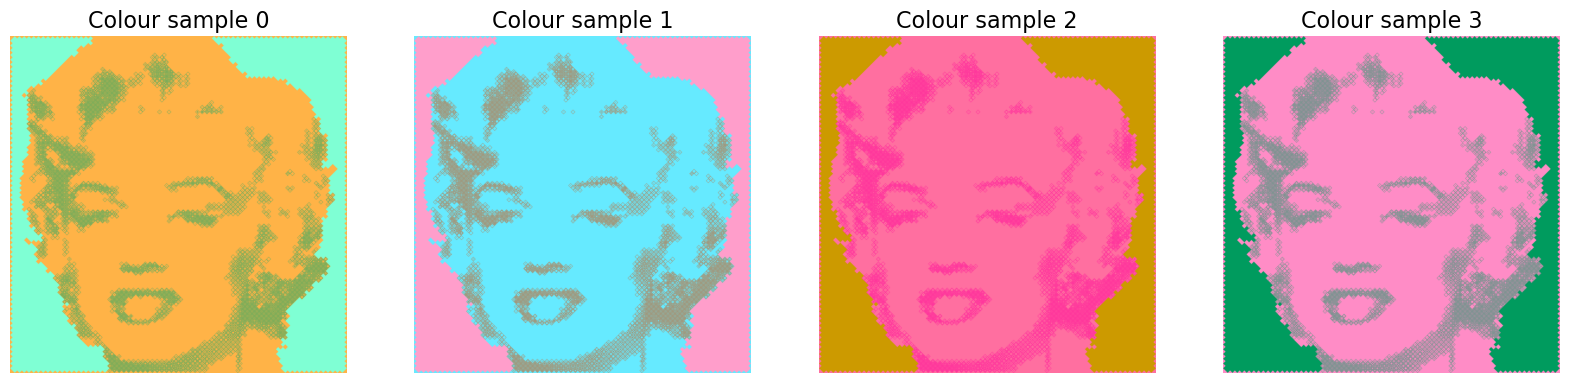

In [ ]:
# create dict of generator classes for each colour sample

n_samples = 4
color_schemes = [ColorScheme.warhol() for _ in range(n_samples)]

generators_grid_sizes = {
    sample: MosaicGenerator(level=level, grid_size=grid_size, color_scheme=color_scheme)
    for sample, color_scheme in enumerate(color_schemes)
}

mosaics_grid_sizes = {
    sample: generator.generate_from_image(input_path, no_eca=no_eca)
    for sample, generator in generators_grid_sizes.items()
}

fig, axs = plt.subplots(1, len(grid_sizes), figsize=(20, 5))

for ax, sample in zip(axs, range(n_samples)):
    ax.imshow(mosaics_grid_sizes[sample])
    ax.set_title(f'Colour sample {sample}', fontsize=16)
    ax.axis('off')

## 4. ECA rules

The background can be decorated further by means of an elementary cellular automaton (ECA). Not that this is independent of the Still Life; it's merely aesthetical.

There are 256 ECAs, and you can choose one and parse it to the generator object. Note, however, that most of these will return rather predictable patterns; by parsing the default choice (`None`), the object selects one of the ECAs that is classified as being either chaotic or complex.

In [43]:
# we'll keep some values fixed in order to only display the effect the Tile level, and remove the ECA background for now
level = 4
grid_size = 100

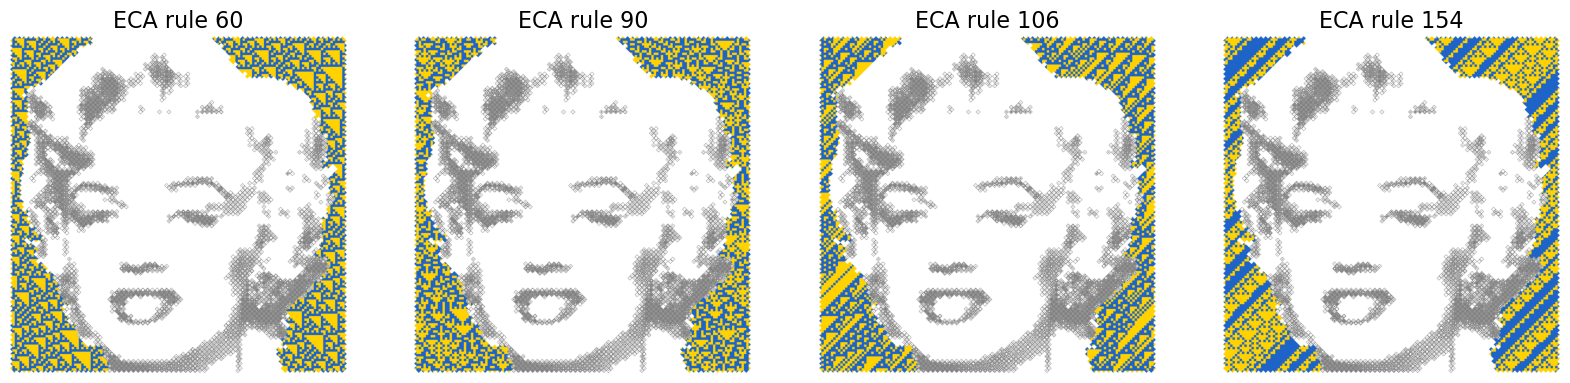

In [45]:
eca_rules = [60, 90, 106, 154]

# create dict of generator classes for each eca_rule

generators_eca_rules = {
    eca_rule: MosaicGenerator(level=level, grid_size=grid_size, eca_rule=eca_rule)
    for eca_rule in eca_rules
}

mosaics_eca_rules = {
    eca_rule: generator.generate_from_image(input_path)
    for eca_rule, generator in generators_eca_rules.items()
}

fig, axs = plt.subplots(1, len(eca_rules), figsize=(20, 5))

for ax, eca_rule in zip(axs, eca_rules):
    ax.imshow(mosaics_eca_rules[eca_rule])
    ax.set_title(f'ECA rule {eca_rule}', fontsize=16)
    ax.axis('off')

## 5. Supersample values

The width of a single cell in the ECA of the background pattern is not identical to the width of a cell in the Game of Life Mosaic portrait. The ratio between the former over the latter is called the supersample value, and we can play around with these.

Note that not all values are allowed, because an exact multiple of the ECA cell width should fit in the output image. If an illegal value is chosen, the algorithm will raise an error and suggest all legal values.

In [54]:
# we'll keep some values fixed in order to only display the effect the Tile level, and remove the ECA background for now
level = 4
grid_size = 100
eca_rule = 106

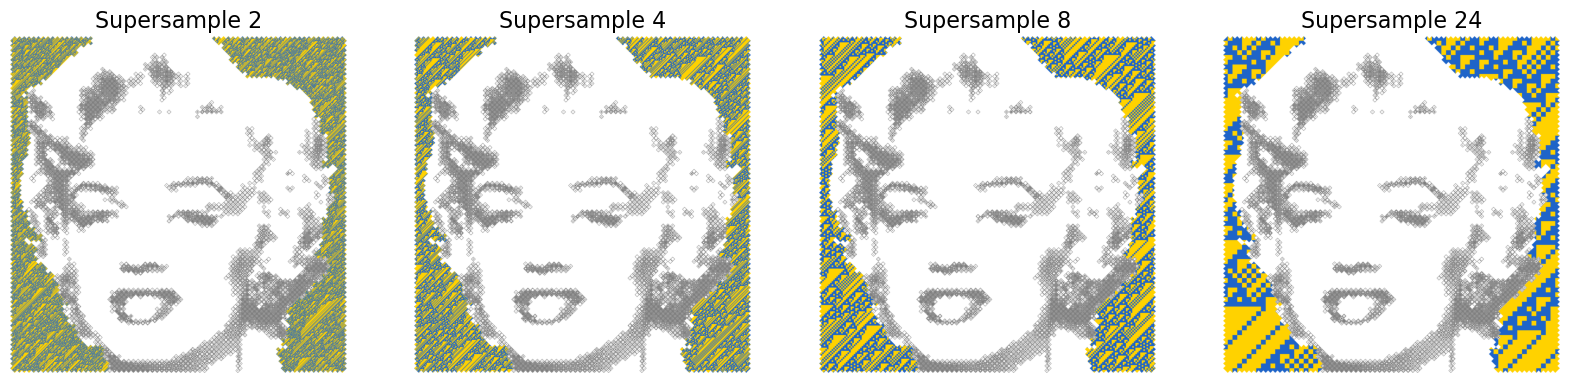

In [55]:
supersample_values = [2, 4, 8, 24]

# create dict of generator classes for each eca_rule

generator_supersamples = MosaicGenerator(level=level, grid_size=grid_size, eca_rule=eca_rule)

mosaics_supersamples = {
    supersample_value: generator_supersamples.generate_from_image(input_path, supersample=supersample_value)
    for supersample_value in supersample_values
}

fig, axs = plt.subplots(1, len(supersample_values), figsize=(20, 5))

for ax, supersample_value in zip(axs, supersample_values):
    ax.imshow(mosaics_supersamples[supersample_value])
    ax.set_title(f'Supersample {supersample_value}', fontsize=16)
    ax.axis('off')

## 6. Threshold values for white or empty tiles

As you can see in the images above, many of the greyscale pixels are actually mapped to no Tile at all. A 'Tile' with only dead cells is of course trivially static, such that adding these empty Tiles still generates a Still Life Mosaic.

We can control the cut-off value for the mapping to empty tiles. That is to say: we can select the greyscale value under which the pixel should map to an empty Tile. All greyscale values above this cut-off value are linearly mapped to Tiles with densities ranging from 0 to 1. A clever choice for the cut-off value has at least two visual effects:
- It clarifies and brightens up the resulting image. After all, if a white pixel is mapped to a Tile with density 0, this Tile still contains quite a few living cells, which still renders relatively grey.
- It creates more greyscale resolution in the remaining colours, because the same number of Tiles is now available for a smaller number of greyscale pixels.

Inspect the images below and you'll know what I mean.

In [63]:
# we'll keep some values fixed in order to only display the effect the Tile level, and remove the ECA background for now
level = 4
grid_size = 100
eca_rule = 54

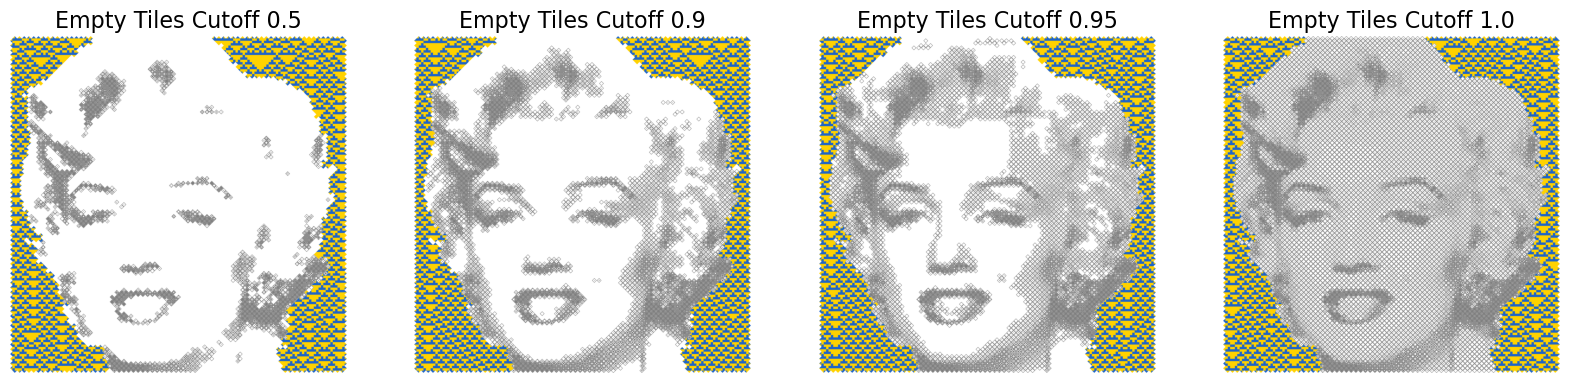

In [64]:
empty_tiles_cutoff_values = [.5, .9, .95, 1.]

# create dict of generator classes for each eca_rule

generator_supersamples = MosaicGenerator(level=level, grid_size=grid_size, eca_rule=eca_rule)

mosaics_supersamples = {
    empty_tiles_cutoff_value: generator_supersamples.generate_from_image(input_path, empty_tiles_cutoff=empty_tiles_cutoff_value)
    for empty_tiles_cutoff_value in empty_tiles_cutoff_values
}

fig, axs = plt.subplots(1, len(empty_tiles_cutoff_values), figsize=(20, 5))

for ax, empty_tiles_cutoff_value in zip(axs, empty_tiles_cutoff_values):
    ax.imshow(mosaics_supersamples[empty_tiles_cutoff_value])
    ax.set_title(f'Empty Tiles Cutoff {empty_tiles_cutoff_value}', fontsize=16)
    ax.axis('off')

## 7. Threshold value for alpha cutoff

The final effect is really subtle and often not even relevant, depending on the nature of the input image. Controlling the cutoff of the alpha channel essentially determines where the ECA background should start overlapping the foreground image.

The input image is an image with no background, but the edge between background and foregrond is typically not sharp, but rather determined by an eight-bit alpha channel value. The `alpha_cutoff` value simply determines the value of the alpha channel that is the threshold value for distinguishing background and foreground.

Again, looking at the images will bring more clarity, although (for non-zero cutoff values) this time you'll have to squint a bit.

In [69]:
# we'll keep some values fixed in order to only display the effect the Tile level, and remove the ECA background for now
level = 4
grid_size = 100
eca_rule = 54

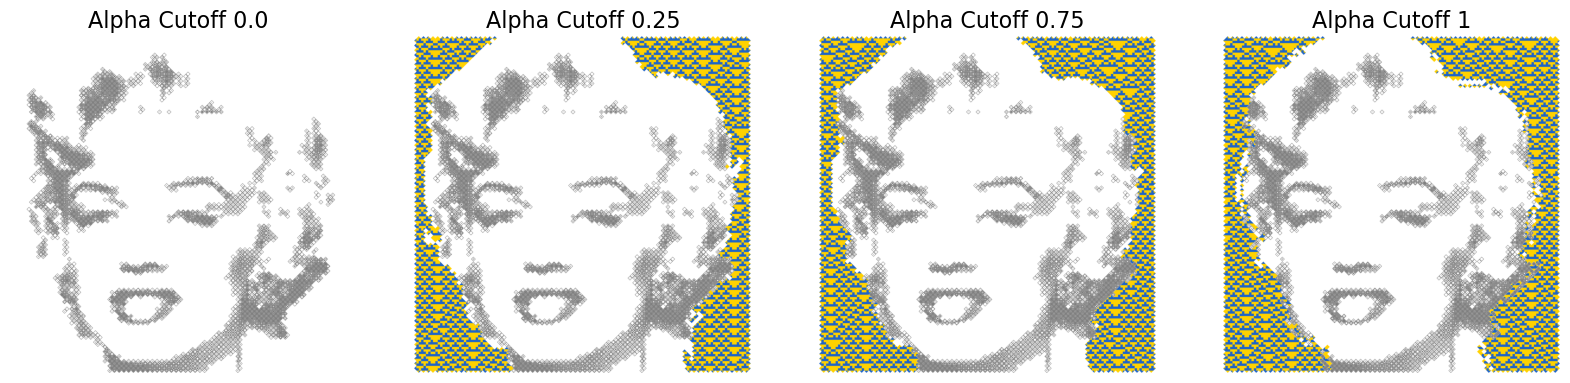

In [70]:
alpha_cutoff_values = [.00, .25, .75, 1]

# create dict of generator classes for each eca_rule

generator_supersamples = MosaicGenerator(level=level, grid_size=grid_size, eca_rule=eca_rule)

mosaics_supersamples = {
    alpha_cutoff_value: generator_supersamples.generate_from_image(input_path, alpha_cutoff = alpha_cutoff_value)
    for alpha_cutoff_value in alpha_cutoff_values
}

fig, axs = plt.subplots(1, len(alpha_cutoff_values), figsize=(20, 5))

for ax, alpha_cutoff_value in zip(axs, alpha_cutoff_values):
    ax.imshow(mosaics_supersamples[alpha_cutoff_value])
    ax.set_title(f'Alpha Cutoff {alpha_cutoff_value}', fontsize=16)
    ax.axis('off')